# Clearcut forest vs. agriculture in Florida — AlphaEarth embeddings

**Method 1 of 2.** Some Florida pixels that LANDFIRE EVT labels as agriculture / grassland / shrubland are, on the ground, **recently clearcut forest**. This notebook asks whether AlphaEarth annual embeddings separate genuine clearcuts from genuine agriculture, and where three commonly-confused EVT classes fall in that embedding space.

The companion notebook `Clearcut-vs-Agriculture-EVT-Change.ipynb` covers **Method 2** (LANDFIRE EVT year-over-year change) and the cross-method comparison.

Design: `docs/superpowers/specs/2026-07-01-clearcut-vs-agriculture-embeddings-design.md`

Confused EVT classes (LF2022 codes): Eastern Warm Temperate Pasture and Hayland (7997), Southeastern Ruderal Grassland (9823), East Gulf Coastal Plain Small Stream and River Floodplain Shrubland (9585).

## 1. Setup
Initialize Earth Engine, load the Florida extent, and import the shared helper module.

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd()
_candidates = [cwd / "notebooks", cwd, *[p / "notebooks" for p in cwd.parents], *cwd.parents]
nb_dir = next(p for p in _candidates if (p / "clearcut_ag_common.py").exists())
sys.path.insert(0, str(nb_dir))

import clearcut_ag_common as cac

REPO_ROOT = cac.find_repo_root(nb_dir)
ee = cac.init_ee()
florida, florida_gdf = cac.load_florida(REPO_ROOT)
print("Repo root:", REPO_ROOT)
print("Florida extent:", florida_gdf[["name", "fips"]].to_dict("records"))

Repo root: /home/chazm/projects/artemis-model
Florida extent: [{'name': 'Florida', 'fips': '12'}]


In [2]:
# Analysis parameters (the event window sits inside AlphaEarth coverage 2017-2024).
PRE_YEAR = cac.DEFAULT_PRE_YEAR       # 2020: reference "still forest" year
EVENT_YEAR = cac.DEFAULT_EVENT_YEAR   # 2022: embeddings + change year
N_CLEARCUT = 300   # points drawn from the LCMS clearcut mask
N_RANDOM = 1500    # random Florida points (source of agriculture + confused samples)

# Manual anchor(s) for the hybrid label set. The first is the Ocala-area clearcut
# used by the existing interactive notebook.
MANUAL_ANCHORS = [
    (-81.8048667, 29.256675),
]

OUT_DIR = REPO_ROOT / "data" / "interim" / "clearcut_ag"
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Build the labeled sample table (hybrid)
`build_sample_table` draws clearcut points from the LCMS mask, random Florida points, and the manual anchors, then attributes each point with the AlphaEarth 64-D vector (event year), LCMS pre/event land cover + change, the 2016 GEE EVT class, and the local LF2022 EVT class. Labels are derived from those attributes.

In [3]:
samples = cac.build_sample_table(
    florida, REPO_ROOT,
    event_year=EVENT_YEAR, pre_year=PRE_YEAR,
    n_clearcut=N_CLEARCUT, n_random=N_RANDOM,
    manual_anchors=MANUAL_ANCHORS,
)
# Drop points off AlphaEarth coverage (e.g. open water -> null embedding).
samples = samples.dropna(subset=list(cac.EMBEDDING_BANDS)).reset_index(drop=True)
print("Usable sampled points:", len(samples))
print(samples["label"].value_counts())

Usable sampled points: 1700
label
other          1129
clearcut        304
confused        182
agriculture      85
Name: count, dtype: int64


In [4]:
import numpy as np
import pandas as pd

emb = list(cac.EMBEDDING_BANDS)
anchors = samples[samples["label"].isin(["clearcut", "agriculture"])].copy()
confused = samples[samples["label"] == "confused"].copy()
print("clearcut anchors:   ", int((anchors.label == "clearcut").sum()))
print("agriculture anchors:", int((anchors.label == "agriculture").sum()))
print("confused points:    ", len(confused), "->", confused["confused_name"].value_counts().to_dict())

clearcut anchors:    304
agriculture anchors: 85
confused points:     182 -> {'pasture_hay': 144, 'ruderal_grass': 37, 'floodplain_shrub': 1}


## 3. Embedding separability — PCA
A 2-D PCA fit on the clean clearcut/agriculture anchors, with the confused-class points projected on top. Visual overlap of a confused class with the clearcut cloud is the first evidence that EVT mislabels clearcuts there.

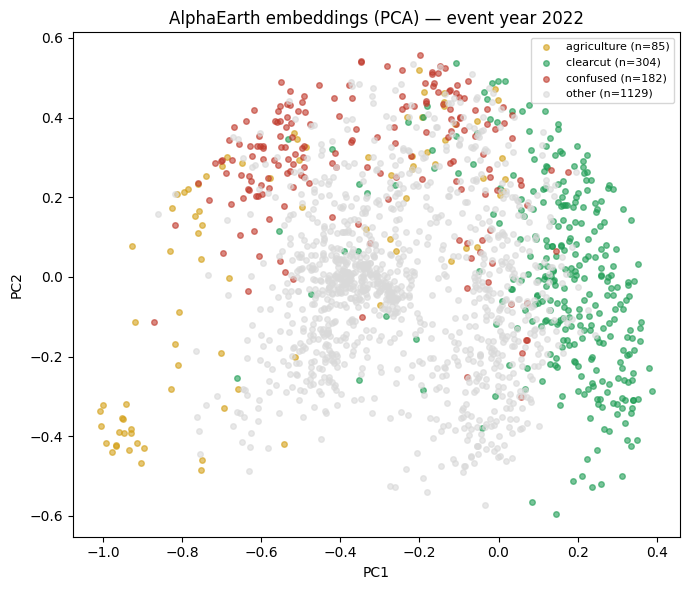

In [5]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=0).fit(anchors[emb].to_numpy())
coords = pca.transform(samples[emb].to_numpy())
samples["pc1"], samples["pc2"] = coords[:, 0], coords[:, 1]

palette = {"agriculture": "#d4a017", "clearcut": "#1f9d55", "confused": "#c0392b", "other": "#d9d9d9"}
fig, ax = plt.subplots(figsize=(7, 6))
for lab, color in palette.items():
    sub = samples[samples["label"] == lab]
    ax.scatter(sub["pc1"], sub["pc2"], s=16, alpha=0.6, c=color, label=f"{lab} (n={len(sub)})")
ax.set(xlabel="PC1", ylabel="PC2", title=f"AlphaEarth embeddings (PCA) — event year {EVENT_YEAR}")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT_DIR / "embeddings_pca.png", dpi=120)
plt.show()

## 4. Centroid cosine distances and silhouette
Class centroids in the full 64-D space. Small centroid distance between a confused class and `clearcut` (vs `agriculture`) means that class looks like clearcut. The silhouette score summarizes how cleanly clearcut and agriculture separate.

In [6]:
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_distances

def centroid(frame):
    return frame[emb].to_numpy().mean(axis=0, keepdims=True)

groups = {
    "clearcut": anchors[anchors.label == "clearcut"],
    "agriculture": anchors[anchors.label == "agriculture"],
}
for value, short in cac.CONFUSED_EVT_SHORT.items():
    sub = confused[confused.confused_name == short]
    if len(sub):
        groups[f"confused:{short}"] = sub

names = list(groups)
cents = np.vstack([centroid(groups[n]) for n in names])
dist_df = pd.DataFrame(cosine_distances(cents), index=names, columns=names).round(3)
print("Centroid cosine distances:")
print(dist_df)

ca = anchors[anchors.label.isin(["clearcut", "agriculture"])]
sil = silhouette_score(ca[emb].to_numpy(), ca["label"], metric="cosine")
print(f"\nSilhouette (clearcut vs agriculture, cosine): {sil:.3f}")

Centroid cosine distances:
                           clearcut  agriculture  confused:pasture_hay  \
clearcut                      0.000        0.437                 0.373   
agriculture                   0.437        0.000                 0.194   
confused:pasture_hay          0.373        0.194                 0.000   
confused:ruderal_grass        0.141        0.272                 0.159   
confused:floodplain_shrub     0.217        0.515                 0.539   

                           confused:ruderal_grass  confused:floodplain_shrub  
clearcut                                    0.141                      0.217  
agriculture                                 0.272                      0.515  
confused:pasture_hay                        0.159                      0.539  
confused:ruderal_grass                      0.000                      0.239  
confused:floodplain_shrub                   0.239                      0.000  

Silhouette (clearcut vs agriculture, cosine): 0.467


## 5. Supervised probe: clearcut vs. agriculture
Train simple classifiers (logistic regression, KNN) on the clean anchors with 5-fold cross-validation. High accuracy means the two classes are genuinely separable in embedding space.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report

train = anchors[anchors.label.isin(["clearcut", "agriculture"])].copy()
X_tr = train[emb].to_numpy()
y_tr = (train.label == "clearcut").astype(int).to_numpy()  # 1 = clearcut

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
for name, clf in [("logreg", LogisticRegression(max_iter=1000)),
                  ("knn", KNeighborsClassifier(n_neighbors=7))]:
    pred = cross_val_predict(clf, X_tr, y_tr, cv=cv)
    print(f"\n== {name} == CV accuracy: {(pred == y_tr).mean():.3f}")
    print(confusion_matrix(y_tr, pred))
    print(classification_report(y_tr, pred, target_names=["agriculture", "clearcut"], zero_division=0))

model = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)  # final model on all anchors


== logreg == CV accuracy: 0.956
[[ 71  14]
 [  3 301]]
              precision    recall  f1-score   support

 agriculture       0.96      0.84      0.89        85
    clearcut       0.96      0.99      0.97       304

    accuracy                           0.96       389
   macro avg       0.96      0.91      0.93       389
weighted avg       0.96      0.96      0.96       389


== knn == CV accuracy: 0.951
[[ 69  16]
 [  3 301]]
              precision    recall  f1-score   support

 agriculture       0.96      0.81      0.88        85
    clearcut       0.95      0.99      0.97       304

    accuracy                           0.95       389
   macro avg       0.95      0.90      0.92       389
weighted avg       0.95      0.95      0.95       389



## 6. Score the confused EVT classes
Apply the fitted clearcut-vs-agriculture model to the confused-class points. A high `mean_clearcut_prob` / `frac_pred_clearcut` for a class means its pixels look like clearcut in embedding space — i.e. EVT is likely mislabeling clearcuts as that class. `frac_lcms_treeremoval` is the independent LCMS check.

In [8]:
if len(confused):
    confused = confused.assign(
        clearcut_prob=model.predict_proba(confused[emb].to_numpy())[:, 1]
    )
    summary = (
        confused.groupby("confused_name")
        .agg(
            n=("clearcut_prob", "size"),
            mean_clearcut_prob=("clearcut_prob", "mean"),
            frac_pred_clearcut=("clearcut_prob", lambda s: float((s > 0.5).mean())),
            frac_lcms_treeremoval=("is_clearcut", "mean"),
        )
        .round(3)
    )
    print(summary)
else:
    print("No confused-class points sampled; raise N_RANDOM.")

                    n  mean_clearcut_prob  frac_pred_clearcut  \
confused_name                                                   
floodplain_shrub    1               0.929               1.000   
pasture_hay       144               0.417               0.340   
ruderal_grass      37               0.688               0.838   

                  frac_lcms_treeremoval  
confused_name                            
floodplain_shrub                  0.000  
pasture_hay                       0.014  
ruderal_grass                     0.000  


## 7. Persist the shared sample table
Write the full attributed table (embeddings, labels, EVT fields, clearcut probability) so the EVT-change notebook analyzes the identical points.

In [9]:
samples["clearcut_prob"] = model.predict_proba(samples[emb].to_numpy())[:, 1]
csv_path = OUT_DIR / "embeddings_samples.csv"
samples.to_csv(csv_path, index=False)
print("Wrote", csv_path)
print("rows:", len(samples), "cols:", samples.shape[1])

Wrote /home/chazm/projects/artemis-model/data/interim/clearcut_ag/embeddings_samples.csv
rows: 1700 cols: 87


## Interpretation notes
- **Separability** (silhouette, CV accuracy) tells you whether embeddings *can* tell clearcut from agriculture at all. If they cannot, Method 2 (EVT change) is the more reliable route.
- **Per-class clearcut share** is the payload: it ranks how badly each of the three EVT classes conflates clearcuts with real agriculture.
- Caveats: `agriculture` anchors are stable EVT row-crop/agricultural pixels, so they are not fully independent of EVT; spatial autocorrelation is not controlled; embeddings are annual composites.